In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, ttest_1samp
from analysis_utils import compute_all_participants, plot_time_on_task, remove_rt_outliers #work in progress

In [2]:
df = pd.read_csv(
    r"C:\Users\lucij\Desktop\Leiden\Year 2\Thesis Project\2024_data\cleaned_long_data_eye_behavior_all.csv"
)

In [13]:
# separate df by instructions
df_inst0 = df[df['instructions'] == 0]
df_inst1 = df[df['instructions'] == 1]

In [14]:
df_rt = df[
    (df['timeout'] == 0) &
    (df['response_time'].notna())
]

In [31]:
df_rt_clean = remove_rt_outliers( #should I remove RT outliers?
    df_rt,
    participant_col='subject',
    rt_col='response_time'
)

#### Checking timeouts

In [ ]:
print("Number of rows in df:", df.shape[0])
print("Number of rows in df_rt:", df_rt.shape[0])
print("Number of rows in df_rt_clean:", df_rt_clean.shape[0])

Number of rows in df: 45000
Number of rows in df_rt: 44713
Number of rows in df_rt_clean: 42645


In [17]:
print(df_rt.shape[0]/df.shape[0])

print(df.shape[0] - df_rt.shape[0])

0.9936222222222222
287


In [21]:
#per instructions

df0_rt = df_inst0[
    (df_inst0['timeout'] == 0) &
    (df_inst0['response_time'].notna())
]

df1_rt = df_inst1[
    (df_inst1['timeout'] == 0) &
    (df_inst1['response_time'].notna())
]


In [25]:
print(df0_rt.shape[0]/df_inst0.shape[0])

print(df_inst0.shape[0] - df0_rt.shape[0])

print(df_inst0.shape[0])
print(df0_rt.shape[0])

0.9876754385964912
281
22800
22519


In [26]:
print(df1_rt.shape[0]/df_inst1.shape[0])

print(df_inst1.shape[0] - df1_rt.shape[0])

print(df_inst1.shape[0])
print(df1_rt.shape[0])

0.9997297297297297
6
22200
22194


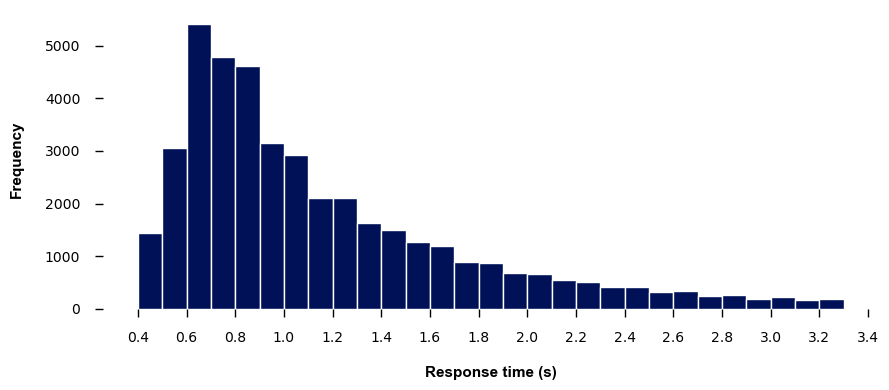

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rt_data = df_rt['response_time'].dropna()  # in seconds

plt.figure(figsize=(9, 4))

bin_width = 0.1 
rt_min = 0.4
rt_max = 3.2
bins = np.arange(rt_min, rt_max + bin_width, bin_width)

plt.hist(
    rt_data,
    bins=bins,
    color='#001158',
    edgecolor='white'
)

plt.xlabel(
    "Response time (s)",
    fontname='Arial',
    fontsize=11,
    fontweight='bold',
    labelpad=15
)
plt.ylabel(
    "Frequency",
    fontname='Arial',
    fontsize=11,
    fontweight='bold',
    labelpad=15
)

xticks = np.arange(rt_min, rt_max + 0.2, 0.2)
plt.xticks(xticks)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis='both',
    which='both',
    length=6,
    width=1,
    direction='out',
    pad=10
)

plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.15)

plt.tight_layout()
plt.show()

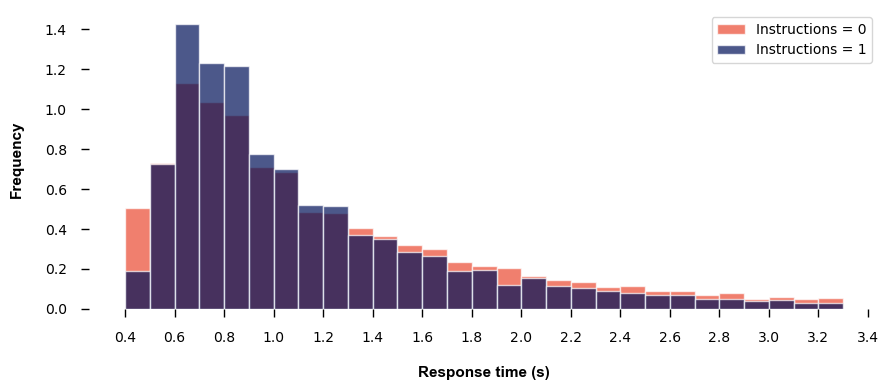

In [49]:
import matplotlib.pyplot as plt
import numpy as np

rt_inst0 = df_inst0['response_time'].dropna()  # in seconds
rt_inst1 = df_inst1['response_time'].dropna()  # in seconds

plt.figure(figsize=(9, 4))

bin_width = 0.1   
rt_min = 0.4
rt_max = 3.2
bins = np.arange(rt_min, rt_max + bin_width, bin_width)

plt.hist(
    rt_inst0,
    bins=bins,
    color='#ea4931',   # orange
    alpha=0.7,
    edgecolor='white',
    density=True,
    label='Instructions = 0'
)

plt.hist(
    rt_inst1,
    bins=bins,
    color='#001158',   # dark blue
    alpha=0.7,
    edgecolor='white',
    density=True,
    label='Instructions = 1'
)

plt.xlabel(
    "Response time (s)",
    fontname='Arial',
    fontsize=11,
    fontweight='bold',
    labelpad=15
)
plt.ylabel(
    "Frequency",
    fontname='Arial',
    fontsize=11,
    fontweight='bold',
    labelpad=15
)

xticks = np.arange(rt_min, rt_max + 0.2, 0.2)
plt.xticks(xticks)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis='both',
    which='both',
    length=6,
    width=1,
    direction='out',
    pad=10
)


plt.legend(fontsize=10)

plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.15)

plt.tight_layout()
plt.show()

In [51]:
# How many unique signed contrast values
num_unique = df_rt_clean['stimContrast'].nunique()
print(f"Number of unique signed contrast values: {num_unique}")

# Optionally, list the unique values
unique_values = df_rt_clean['stimContrast'].unique()
print(np.sort(unique_values))


Number of unique signed contrast values: 5
[0.   0.02 0.05 0.1  0.2 ]


In [55]:
# Count trials per signed contrast
contrast_counts = df1_rt['stimContrast'].value_counts().sort_index()


In [56]:
# Compute mean RT for each signed contrast
rt_by_contrastDelta = df1_rt.groupby('stimContrast')['response_time'].mean().reset_index()


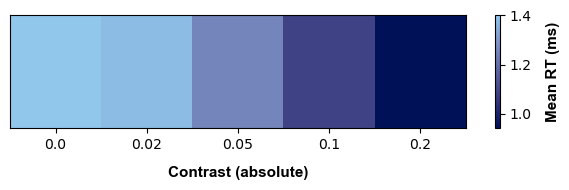

In [58]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Categorical X-axis
categories = rt_by_contrastDelta['stimContrast'].astype(str).values
rt_values = rt_by_contrastDelta['response_time'].values

plt.figure(figsize=(6, 2))  # short height for strip-style heatmap

# Create a continuous colormap from your palette
palette = ["#001158", "#36387b", "#5c63a0", "#7d92c6", "#91c7eb"]


cmap = mcolors.LinearSegmentedColormap.from_list("custom_palette", palette)

# Plot as 1-row heatmap using imshow
plt.imshow(
    rt_values[np.newaxis, :],         # shape (1, 5)
    aspect='auto',
    cmap=cmap,
    extent=[-0.5, len(categories)-0.5, 0, 1]  # center each category
)

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Mean RT (ms)', fontname='Arial', fontsize=11, fontweight='bold', labelpad=10)  # space between y-axis title and graph

# X-axis: set ticks to match categories
plt.xticks(ticks=np.arange(len(categories)), labels=categories)
plt.yticks([])  # hide y-axis

# Labels
plt.xlabel('Contrast (absolute)', fontname='Arial', fontsize=11, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()


In [60]:

from itertools import combinations
from scipy.stats import ttest_rel

# Step 1: compute mean RT per participant per stimContrast
participant_rt = df1_rt.groupby(['subject', 'stimContrast'])['response_time'].mean().reset_index()

# Pivot to wide format
rt_wide = participant_rt.pivot(index='subject', columns='stimContrast', values='response_time')

# Step 2: paired t-tests for all pairs of stimContrast
contrast_values = [0, 0.02, 0.05, 0.1, 0.2]
results = []

for a, b in combinations(contrast_values, 2):
    t_stat, p_val = ttest_rel(rt_wide[a], rt_wide[b])
    results.append({
        'contrast1': a,
        'contrast2': b,
        't_stat': t_stat,
        'p_value': p_val
    })

ttest_results = pd.DataFrame(results)

# Step 3: Bonferroni correction
ttest_results['p_adj'] = ttest_results['p_value'] * len(ttest_results)  # multiply by 10 comparisons
ttest_results['p_adj'] = ttest_results['p_adj'].clip(upper=1.0)         # cap at 1

# Show results
print(ttest_results)


   contrast1  contrast2    t_stat       p_value         p_adj
0       0.00       0.02  2.118750  4.107953e-02  4.107953e-01
1       0.00       0.05  5.620132  2.237594e-06  2.237594e-05
2       0.00       0.10  7.293637  1.357373e-08  1.357373e-07
3       0.00       0.20  8.117856  1.190461e-09  1.190461e-08
4       0.02       0.05  6.797576  6.059635e-08  6.059635e-07
5       0.02       0.10  8.086743  1.303268e-09  1.303268e-08
6       0.02       0.20  8.673265  2.410692e-10  2.410692e-09
7       0.05       0.10  7.077531  2.598131e-08  2.598131e-07
8       0.05       0.20  8.430022  4.829704e-10  4.829704e-09
9       0.10       0.20  7.943995  1.977177e-09  1.977177e-08


In [62]:
from scipy.stats import linregress

# Compute mean RT per participant per stimContrast
participant_rt = df_rt_clean.groupby(['subject', 'stimContrast'])['response_time'].mean().reset_index()

# Now regress: RT ~ stimContrast
slope, intercept, r_value, p_value, std_err = linregress(participant_rt['stimContrast'], participant_rt['response_time'])

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.6f}")



Slope: -1.53
Intercept: 1.28
R-squared: 0.083
P-value: 0.000000


In [64]:


# Mean accuracy per participant per stimContrast
participant_acc = df1_rt.groupby(['subject', 'stimContrast'])['feedbackType'].mean().reset_index()

# Compute mean accuracy across participants per stimContrast
acc_by_contrast = participant_acc.groupby('stimContrast')['feedbackType'].mean().reset_index()
acc_by_contrast = acc_by_contrast.sort_values('stimContrast')

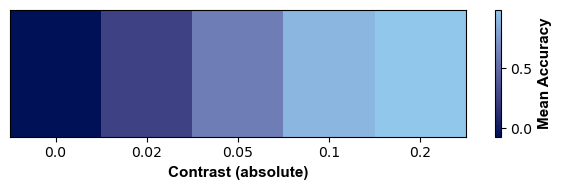

In [67]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.figure(figsize=(6, 2))  # short height to mimic heatmap

# Continuous colormap (blue gradient)
palette = ["#001158", "#36387b", "#5c63a0", "#7d92c6", "#91c7eb"]
cmap = mcolors.LinearSegmentedColormap.from_list("accuracy_palette", palette)

# 1-row heatmap
plt.imshow(
    acc_by_contrast['feedbackType'].values[np.newaxis, :],  # shape (1, 5)
    aspect='auto',
    cmap=cmap,
    extent=[-0.5, len(acc_by_contrast)-0.5, 0, 1]  # center each category
)

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Mean Accuracy', fontname='Arial', fontsize=11, fontweight='bold')

# X-axis: only the existing stimContrast values
plt.xticks(ticks=np.arange(len(acc_by_contrast)), labels=acc_by_contrast['stimContrast'].values)
plt.yticks([])  # hide Y-axis

# Labels
plt.xlabel('Contrast (absolute)', fontname='Arial', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [68]:
from itertools import combinations
from scipy.stats import ttest_rel
import pandas as pd

# Pivot participant-level mean accuracy to wide format
acc_wide = participant_acc.pivot(index='subject', columns='stimContrast', values='feedbackType')

# Stim contrast values
contrast_values = [0, 0.02, 0.05, 0.1, 0.2]

results = []

for a, b in combinations(contrast_values, 2):
    t_stat, p_val = ttest_rel(acc_wide[a], acc_wide[b])
    results.append({
        'contrast1': a,
        'contrast2': b,
        't_stat': t_stat,
        'p_value': p_val
    })

ttest_acc = pd.DataFrame(results)

# Bonferroni correction for 10 comparisons
ttest_acc['p_adj'] = (ttest_acc['p_value'] * len(ttest_acc)).clip(upper=1.0)

print(ttest_acc)


   contrast1  contrast2     t_stat       p_value         p_adj
0       0.00       0.02 -13.535049  1.086212e-15  1.086212e-14
1       0.00       0.05 -25.542241  1.158907e-24  1.158907e-23
2       0.00       0.10 -34.006760  5.814774e-29  5.814774e-28
3       0.00       0.20 -38.702937  6.232554e-31  6.232554e-30
4       0.02       0.05 -19.291575  1.439223e-20  1.439223e-19
5       0.02       0.10 -39.789564  2.351727e-31  2.351727e-30
6       0.02       0.20 -49.131384  1.357109e-34  1.357109e-33
7       0.05       0.10 -23.667436  1.551118e-23  1.551118e-22
8       0.05       0.20 -24.446621  5.165365e-24  5.165365e-23
9       0.10       0.20  -9.711304  1.350827e-11  1.350827e-10


In [69]:
from scipy.stats import linregress

# Flatten participant-level mean accuracy
slope, intercept, r_value, p_value, std_err = linregress(participant_acc['stimContrast'], participant_acc['feedbackType'])

# Print nicely
print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value: {p_value:.6f}")


Slope: 4.888
Intercept: 0.175
R-squared: 0.730
P-value: 0.000000


In [70]:
# Participant-level mean RT and SD
participant_summary = df1_rt.groupby('subject').agg(
    mean_RT=('response_time', 'mean'),
    sd_RT=('response_time', 'std'),
    mean_acc=('feedbackType', 'mean')
).reset_index()

print(participant_summary)


    subject   mean_RT     sd_RT  mean_acc
0        13  1.308845  0.591065  0.583333
1        17  1.276370  0.658861  0.660000
2        18  1.962783  1.230532  0.555927
3        21  0.851390  0.319514  0.663333
4        22  1.700463  0.847160  0.560000
5        25  0.826745  0.358551  0.560000
6        26  0.965358  0.524006  0.673333
7        29  0.898883  0.458874  0.526667
8        30  1.053922  0.397462  0.556667
9        33  1.546700  1.424422  0.576667
10       34  0.876095  0.411698  0.616667
11       37  1.582677  0.775432  0.676667
12       38  0.903132  0.520654  0.573333
13       41  1.059215  0.482322  0.626667
14       42  1.268525  0.688102  0.570000
15       45  1.467193  1.012286  0.590000
16       46  1.719322  0.689398  0.543333
17       49  0.895648  0.533967  0.683333
18       53  1.183553  0.734700  0.626667
19       54  1.505682  0.645614  0.583333
20       57  0.951575  0.349205  0.583333
21       61  1.375835  0.848216  0.649416
22       62  1.365175  0.641436  0

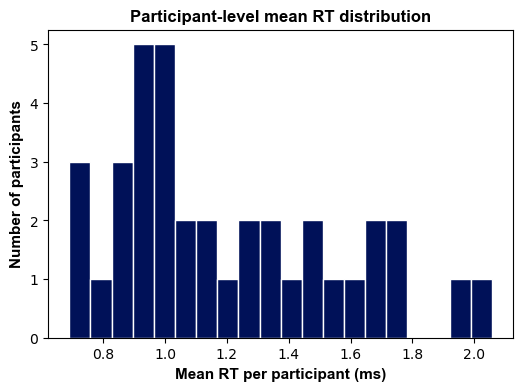

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(participant_summary['mean_RT'], bins=20, color="#001158", edgecolor='white')
plt.xlabel('Mean RT per participant (ms)', fontname='Arial', fontsize=11, fontweight='bold')
plt.ylabel('Number of participants', fontname='Arial', fontsize=11, fontweight='bold')
plt.title('Participant-level mean RT distribution', fontname='Arial', fontsize=12, fontweight='bold')
plt.show()


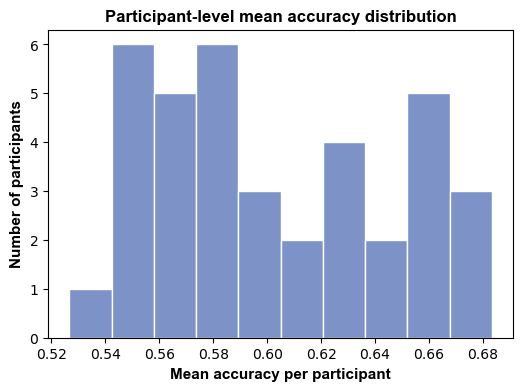

In [73]:
plt.figure(figsize=(6,4))
plt.hist(participant_summary['mean_acc'], bins=10, color="#7d92c6", edgecolor='white')
plt.xlabel('Mean accuracy per participant', fontname='Arial', fontsize=11, fontweight='bold')
plt.ylabel('Number of participants', fontname='Arial', fontsize=11, fontweight='bold')
plt.title('Participant-level mean accuracy distribution', fontname='Arial', fontsize=12, fontweight='bold')
plt.show()


In [74]:
# Participants with very fast or very slow mean RTs
fast_threshold = participant_summary['mean_RT'].mean() - 3*participant_summary['mean_RT'].std()
slow_threshold = participant_summary['mean_RT'].mean() + 3*participant_summary['mean_RT'].std()
extreme_RT = participant_summary[(participant_summary['mean_RT'] < fast_threshold) |
                                 (participant_summary['mean_RT'] > slow_threshold)]

# Participants with near-ceiling or near-floor accuracy
extreme_acc = participant_summary[(participant_summary['mean_acc'] < 0.5) | 
                                  (participant_summary['mean_acc'] > 0.95)]

print("Extreme RT participants:\n", extreme_RT)
print("Extreme accuracy participants:\n", extreme_acc)


Extreme RT participants:
 Empty DataFrame
Columns: [subject, mean_RT, sd_RT, mean_acc]
Index: []
Extreme accuracy participants:
 Empty DataFrame
Columns: [subject, mean_RT, sd_RT, mean_acc]
Index: []


In [78]:
participant_acc = (
    df1_rt
    .groupby(['subject', 'stimContrast'])['feedbackType']
    .mean()
    .reset_index()
)

participant_acc.query("stimContrast == 0.2")['feedbackType'].describe()


count    37.000000
mean      0.987968
std       0.017971
min       0.915966
25%       0.983193
50%       1.000000
75%       1.000000
max       1.000000
Name: feedbackType, dtype: float64